In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.datasets import fetch_openml
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report, roc_curve, auc, average_precision_score
)
from sklearn.model_selection import train_test_split
from scipy.stats import ttest_rel, wilcoxon
import warnings
warnings.filterwarnings('ignore')

import os

os.makedirs('charts', exist_ok=True)

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

print("✓ All imports successful")


RANDOM_STATE = 42   # fixed seed -> same split every time we re-run this notebook
pd.set_option('display.max_columns', 50)
sns.set_theme(style="whitegrid")


✓ All imports successful


In [69]:
# Column names, per the official UCI documentation for this dataset
column_names = [
"age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

dataset = fetch_openml('adult', version=2, as_frame=True)
df = dataset.frame

df.replace('?', np.nan, inplace=True)

print("Shape:", df.shape)
df.head()

Shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [70]:
df.rename(columns={'class': 'income'}, inplace=True)

# Converts the target to binary 0/1.
# income comes in as '<=50K' or '>50K' (sometimes with a trailing period in some mirrors)
df["income"] = df["income"].str.strip().str.rstrip(".")
df["target"] = (df["income"] == ">50K").astype(int)

df[["income", "target"]].drop_duplicates()
df.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,target
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K,0


In [71]:
# Column types and missingness
print(df.dtypes)
missing = df.isna().sum()
print(missing,"\n")
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)
print()
print(f"Total missing cells: {df.isna().sum().sum()} "
      f"({df.isna().sum().sum() / df.size:.2%} of all cells)")


age                  int64
workclass         category
fnlwgt               int64
education         category
education-num        int64
marital-status    category
occupation        category
relationship      category
race              category
sex               category
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country    category
income              object
target               int64
dtype: object
age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
target               0
dtype: int64 

Columns with missing values:
occupation        2809
workclass         2799
native-country     857
dtype: int64

Total missing cells: 6465 (0.83% of all cells)


In [72]:
# Numeric summaries
numeric_cols = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
df[numeric_cols].describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [73]:
# Value counts for a few key categorical columns
for col in ["workclass", "education", "marital-status", "occupation", "sex", "race"]:
    print(f" --- {col} ")
    print(df[col].value_counts(dropna=False).head(8))
    print()


 --- workclass 
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
NaN                  2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Name: count, dtype: int64

 --- education 
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
Name: count, dtype: int64

 --- marital-status 
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

 --- occupation 
occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
NaN                 

In [74]:
# Class base rate -- how many people actually earn >50K?
base_rate = df["target"].mean()
class_counts = df["target"].value_counts().rename({0: "<=50K", 1: ">50K"})
print(class_counts)
print(f"\nBase rate (positive class share): {base_rate:.2%}")


target
<=50K    37155
>50K     11687
Name: count, dtype: int64

Base rate (positive class share): 23.93%


In [75]:
# 80% train+dev / 20% hold-out test, stratified on the target
train_dev_df, test_df = train_test_split(
    df, test_size=0.20, stratify=df["target"], random_state=RANDOM_STATE
)

# Optional further split: carve a dev set out of the remaining 80%
# (10% of the ORIGINAL data -> 12.5% of train_dev_df, since train_dev_df is 80% of total)
train_df, dev_df = train_test_split(
    train_dev_df, test_size=0.125, stratify=train_dev_df["target"], random_state=RANDOM_STATE
) # will be used later , reserved for tommorow

print(f"Train size: {len(train_df)}  ({len(train_df)/len(df):.1%} of full data)")
print(f"Dev size:   {len(dev_df)}   ({len(dev_df)/len(df):.1%} of full data)")
print(f"Test size:  {len(test_df)}  ({len(test_df)/len(df):.1%} of full data)")
print()
print("Class balance check (share of positives in each split):")
for name, part in [("Full data", df), ("Train", train_df), ("Dev", dev_df), ("Test (hold-out)", test_df)]:
    print(f"  {name:18s}: {part['target'].mean():.2%}")


Train size: 34188  (70.0% of full data)
Dev size:   4885   (10.0% of full data)
Test size:  9769  (20.0% of full data)

Class balance check (share of positives in each split):
  Full data         : 23.93%
  Train             : 23.93%
  Dev               : 23.93%
  Test (hold-out)   : 23.93%


In [76]:
# Baseline 1: Majority-class predictor
majority_class = train_df["target"].mode()[0]
print(f"Majority class in training data: {majority_class} "
      f"({'<=50K' if majority_class == 0 else '>50K'})")

y_test = test_df["target"].values
y_pred_majority = np.full_like(y_test, fill_value=majority_class)
# "Probability" for a constant predictor -- use the class itself as a degenerate score
y_score_majority = y_pred_majority.astype(float)


Majority class in training data: 0 (<=50K)


In [77]:
# Baseline 2: Single-feature rule
# Rule: predict >50K if education-num >= 13 OR capital-gain > 0
def rule_predict(frame):
    return ((frame["education-num"] >= 13) | (frame["capital-gain"] > 0)).astype(int)

y_pred_rule = rule_predict(test_df).values
# A simple continuous "score" version for ROC/PR AUC: combine both signals into one number
y_score_rule = (
    (test_df["education-num"] / test_df["education-num"].max()) * 0.5
    + (test_df["capital-gain"] > 0).astype(float) * 0.5
).values


In [78]:
def evaluate(y_true, y_pred, y_score, name):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
    }

results = [
    evaluate(y_test, y_pred_majority, y_score_majority, "Majority-class"),
    evaluate(y_test, y_pred_rule, y_score_rule, "Rule-based (education-num>=13 OR capital-gain>0)"),
]
results_df = pd.DataFrame(results).set_index("model").round(4)
results_df


,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Majority-class,0.7607,0.0000,0.0000,0.0000,0.5000,0.2393
Rule-based (education-num>=13 OR capital-gain>0),0.7520,0.4852,0.5967,0.5352,0.7493,0.5079


In [79]:
rule_f1 = results_df.loc["Rule-based (education-num>=13 OR capital-gain>0)", "f1"]
rule_auc = results_df.loc["Rule-based (education-num>=13 OR capital-gain>0)", "roc_auc"]
major_f1 = results_df.loc["Majority-class", "f1"]
major_acc = results_df.loc["Majority-class", "accuracy"]
print(rule_f1)
print(rule_auc)
print(major_f1)
print(major_acc)



0.5352
0.7493
0.0
0.7607


#### Defining Numeric and Categorical Columns

In [80]:
# df.head(10)

categorical_cols = ["workclass", "marital-status", "occupation", "relationship",
                         "race", "sex", "native-country"]

# numeric features already defined yeaterday as numeric_cols

# combined feautres
feature_cols = numeric_cols + categorical_cols

# No need to replace "?" -> NaN, it's already done yesterday.

# Train and test data
X_train, y_train = train_df[feature_cols], train_df["target"]
X_dev,   y_dev = dev_df[feature_cols],   dev_df["target"]
X_test_feature = test_df[feature_cols]   # y_test already exists from Day 1 as a numpy array

#### Building a sklearn ColumnTransformer pipeline

In [81]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
        ('num', numeric_pipeline, numeric_cols),
        ('cat', categorical_pipeline, categorical_cols)
])


Fitting both on the training set only. Did not touch the hold-out test set here.

In [82]:
# Model 1
logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE))
    # lbfgs use L2 refulariztion
    ])
logistic_pipeline.fit(X_train, y_train)

# Model 2
decision_tree_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE))
])
decision_tree_pipeline.fit(X_train, y_train)

print("Both models fitted while holding out test data for evaluation")

Both models fitted while holding out test data for evaluation


In [83]:
y_pred_log_reg = logistic_pipeline.predict(X_test_feature)
y_score_log_reg = logistic_pipeline.predict_proba(X_test_feature)[:, 1]

y_pred_dec_tree = decision_tree_pipeline.predict(X_test_feature)
y_score_dec_tree = decision_tree_pipeline.predict_proba(X_test_feature)[:, 1]

result_2 = [
    evaluate(y_test, y_pred_log_reg, y_score_log_reg, "LogisticRegression"),
    evaluate(y_test, y_pred_dec_tree, y_score_dec_tree, "DescisionTree")
]

result_2_df = pd.DataFrame(result_2).set_index("model").round(4)

# comaparison from day1
comparison_df = pd.concat([results_df, result_2_df])

display(comparison_df)


,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Majority-class,0.7607,0.0000,0.0000,0.0000,0.5000,0.2393
Rule-based (education-num>=13 OR capital-gain>0),0.7520,0.4852,0.5967,0.5352,0.7493,0.5079
LogisticRegression,0.8528,0.7399,0.5937,0.6588,0.9032,0.7607
DescisionTree,0.8538,0.7658,0.5607,0.6474,0.8823,0.6981


#### Confusion Matrix

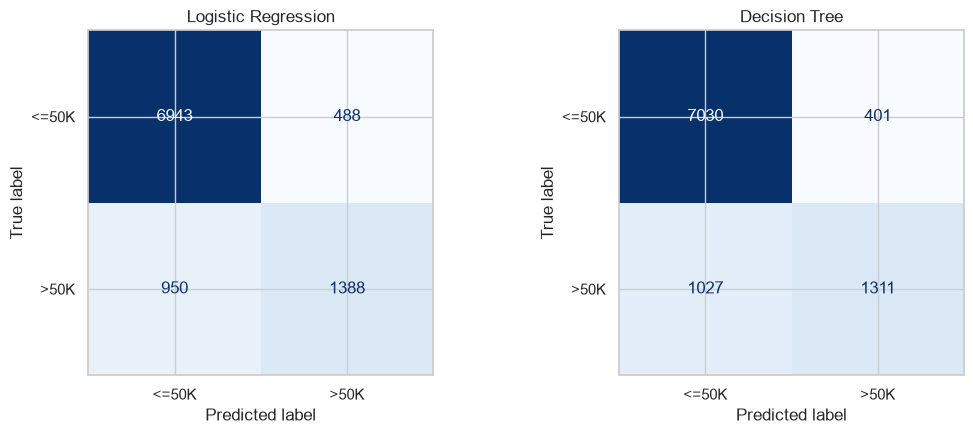

In [84]:
confusion_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)
confusion_matrix_dec_tree = confusion_matrix(y_test, y_pred_dec_tree)

# Confusion matrices for both models
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

confusion_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)
ConfusionMatrixDisplay(confusion_matrix_log_reg, display_labels=["<=50K", ">50K"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Logistic Regression")

confusion_matrix_dec_tree = confusion_matrix(y_test, y_pred_dec_tree)
ConfusionMatrixDisplay(confusion_matrix_dec_tree, display_labels=["<=50K", ">50K"]).plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Decision Tree")

plt.tight_layout()
plt.show()

Logistic Regression:

In [85]:
feature_names = logistic_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefs = logistic_pipeline.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefs}).sort_values(
    "coefficient", ascending=False
)

top_positive = coef_df.head(10).reset_index(drop=True)
top_negative = coef_df.tail(10).sort_values("coefficient").reset_index(drop=True)

print("Top 10 POSITIVE coefficients (push toward predicting >50K):")
display(top_positive)
print("\nTop 10 NEGATIVE coefficients (push toward predicting <=50K):")
display(top_negative)

Top 10 POSITIVE coefficients (push toward predicting >50K):


,feature,coefficient
0,num__capital-gain,2.218460
1,cat__marital-status_Married-civ-spouse,1.596623
2,cat__marital-status_Married-AF-spouse,1.274892
3,cat__native-country_Ireland,0.911378
4,cat__native-country_France,0.848947
5,cat__occupation_Exec-managerial,0.809476
6,cat__relationship_Wife,0.806245
7,num__education-num,0.769411
8,cat__native-country_England,0.755397
9,cat__native-country_Iran,0.668031



Top 10 NEGATIVE coefficients (push toward predicting <=50K):


,feature,coefficient
0,cat__occupation_Priv-house-serv,-1.353548
1,cat__marital-status_Never-married,-1.190421
2,cat__native-country_Columbia,-1.090962
3,cat__native-country_South,-0.978931
4,cat__relationship_Other-relative,-0.919120
5,cat__occupation_Farming-fishing,-0.916071
6,cat__sex_Female,-0.901089
7,cat__occupation_Other-service,-0.834307
8,cat__marital-status_Separated,-0.802523
9,cat__relationship_Own-child,-0.791138


Decision Tree: tree depth and train vs. test score (to check for overfitting).

In [86]:
tree_clf = decision_tree_pipeline.named_steps["classifier"]
train_score = decision_tree_pipeline.score(X_train, y_train)
test_score = decision_tree_pipeline.score(X_test_feature, y_test)

print(f"Tree depth: {tree_clf.get_depth()}")
print(f"Tree leaves: {tree_clf.get_n_leaves()}")
print(f"Train accuracy: {train_score:.4f}")
print(f"Test accuracy:  {test_score:.4f}")
print(f"Train - Test gap: {train_score - test_score:.4f}")

Tree depth: 5
Tree leaves: 29
Train accuracy: 0.8519
Test accuracy:  0.8538
Train - Test gap: -0.0019


## Task 1: Create & Justify Engineered Features

### Feature Dictionary with Predictive Scores

In [87]:
AGE_BINS = [0, 25, 35, 45, 55, 65, 100]
AGE_LABELS = ["<=25", "26-35", "36-45", "46-55", "56-65", "65+"]

HOURS_BINS = [0, 20, 35, 40, 50, 100]
HOURS_LABELS = ["part_time_le20", "reduced_21_35", "standard_36_40", "over_41_50", "heavy_50plus"]

def engineer_features(frame):
    """
    Adds 8 new columns to a copy of the input dataframe.
    Every rule below only reads columns that already exist on that same row,
    so this function is safe to apply identically to train, dev, and test data
    without ever peeking at the target or at other rows.
    """
    new_fe = frame.copy()

    new_fe["age_bucket"] = pd.cut(new_fe["age"], bins=AGE_BINS, labels=AGE_LABELS, right=True).astype(str)
    new_fe["hours_bucket"] = pd.cut(new_fe["hours-per-week"], bins=HOURS_BINS, labels=HOURS_LABELS, right=True).astype(str)

    new_fe["has_capital_gain"] = (new_fe["capital-gain"] > 0).astype(int)
    new_fe["has_capital_loss"] = (new_fe["capital-loss"] > 0).astype(int)
    new_fe["higher_education"] = (new_fe["education-num"] >= 13).astype(int)

    new_fe["log_capital_gain"] = np.log1p(new_fe["capital-gain"])
    new_fe["edu_hours_interaction"] = new_fe["education-num"] * new_fe["hours-per-week"]
    new_fe["net_capital"] = new_fe["capital-gain"] - new_fe["capital-loss"]

    return new_fe

# Apply engineering
df_eng = engineer_features(train_df)

print("✓ Features engineered successfully")
print(f"\nNew feature count: {len(df_eng.columns) - len(df.columns)}")
print(f"Total features: {df_eng.shape[1]}")

✓ Features engineered successfully

New feature count: 8
Total features: 24


In [88]:
new_num_fe = ["log_capital_gain", "edu_hours_interaction", "net_capital"]
new_bol_fe = ["has_capital_gain", "has_capital_loss", "higher_education"]
new_cat_fe = ["age_bucket", "hours_bucket"]

mi_scores = {}

# Mutual info 
for col in new_num_fe + new_bol_fe:
    is_discrete = col in new_bol_fe
    mi = mutual_info_classif(
        df_eng[[col]], df_eng["target"],
        discrete_features=[is_discrete], random_state=RANDOM_STATE
    )
    mi_scores[col] = mi[0]


# Mutual info for categories
for col in new_cat_fe:
    dummies = pd.get_dummies(df_eng[col])
    mi = mutual_info_classif(dummies, df_eng["target"], discrete_features=True, random_state=RANDOM_STATE)
    mi_scores[col] = mi.sum()

print("Mutual information scores (higher = more univariate signal):")
for name, score in sorted(mi_scores.items(), key=lambda x: -x[1]):
    print(f"  {name:24s}: {score:.4f}")
  
print("\nGrouped mean of target by age_bucket:")
print(df_eng.groupby("age_bucket")["target"].mean().reindex(AGE_LABELS))

print("\nGrouped mean of target by hours_bucket:")
print(df_eng.groupby("hours_bucket")["target"].mean().reindex(HOURS_LABELS))

Mutual information scores (higher = more univariate signal):
  net_capital             : 0.1196
  edu_hours_interaction   : 0.0816
  log_capital_gain        : 0.0799
  age_bucket              : 0.0723
  higher_education        : 0.0488
  hours_bucket            : 0.0428
  has_capital_gain        : 0.0291
  has_capital_loss        : 0.0085

Grouped mean of target by age_bucket:
age_bucket
<=25     0.018122
26-35    0.186233
36-45    0.347341
46-55    0.388039
56-65    0.316041
65+      0.191943
Name: target, dtype: float64

Grouped mean of target by hours_bucket:
hours_bucket
part_time_le20    0.074694
reduced_21_35     0.096248
standard_36_40    0.209037
over_41_50        0.390973
heavy_50plus      0.407915
Name: target, dtype: float64


In [89]:
# Feature dictionary
feature_dict = pd.DataFrame([
    {"name": "age_bucket", "type": "categorical (binned)",
     "creation_rule": "pd.cut(age, fixed bins [0,25,35,45,55,65,100])",
     "justification": "Income rises then plateaus with age, a non-monotonic pattern a linear term on raw age cannot capture",
     "mi_score": mi_scores["age_bucket"]},
    {"name": "hours_bucket", "type": "categorical (binned)",
     "creation_rule": "pd.cut(hours-per-week, fixed bins [0,20,35,40,50,100])",
     "justification": "Part time, standard, and overtime work likely have distinct, non-linear pay relationships",
     "mi_score": mi_scores["hours_bucket"]},
    {"name": "has_capital_gain", "type": "binary flag",
     "creation_rule": "capital-gain > 0",
     "justification": "Day 2 found capital-gain behaves like a threshold signal, not a continuous one, this isolates that",
     "mi_score": mi_scores["has_capital_gain"]},
    {"name": "has_capital_loss", "type": "binary flag",
     "creation_rule": "capital-loss > 0",
     "justification": "Same threshold logic as capital gain, any recorded loss may signal investment activity",
     "mi_score": mi_scores["has_capital_loss"]},
    {"name": "higher_education", "type": "binary flag",
     "creation_rule": "education-num >= 13",
     "justification": "A Bachelor's degree or higher is a natural, interpretable cutoff instead of a raw ordinal count",
     "mi_score": mi_scores["higher_education"]},
    {"name": "log_capital_gain", "type": "numeric transform",
     "creation_rule": "log1p(capital-gain)",
     "justification": "Compresses the extreme right tail, useful for tree splits even though it hurt raw scaled LogReg on Day 2",
     "mi_score": mi_scores["log_capital_gain"]},
    {"name": "edu_hours_interaction", "type": "numeric interaction",
     "creation_rule": "education-num * hours-per-week",
     "justification": "Captures a compounding effect, highly educated people working long hours may earn disproportionately more",
     "mi_score": mi_scores["edu_hours_interaction"]},
    {"name": "net_capital", "type": "numeric",
     "creation_rule": "capital-gain - capital-loss",
     "justification": "Nets gains and losses into one investment-activity signal instead of two separate columns",
     "mi_score": mi_scores["net_capital"]},
]).sort_values("mi_score", ascending=False).reset_index(drop=True)

feature_dict

,name,type,creation_rule,justification,mi_score
0,net_capital,numeric,capital-gain - capital-loss,Nets gains and losses into one investment-acti...,0.119564
1,edu_hours_interaction,numeric interaction,education-num * hours-per-week,"Captures a compounding effect, highly educated...",0.081588
2,log_capital_gain,numeric transform,log1p(capital-gain),"Compresses the extreme right tail, useful for ...",0.079856
3,age_bucket,categorical (binned),"pd.cut(age, fixed bins [0,25,35,45,55,65,100])","Income rises then plateaus with age, a non-mon...",0.072318
4,higher_education,binary flag,education-num >= 13,"A Bachelor's degree or higher is a natural, in...",0.048813
5,hours_bucket,categorical (binned),"pd.cut(hours-per-week, fixed bins [0,20,35,40,...","Part time, standard, and overtime work likely ...",0.042838
6,has_capital_gain,binary flag,capital-gain > 0,Day 2 found capital-gain behaves like a thresh...,0.029113
7,has_capital_loss,binary flag,capital-loss > 0,"Same threshold logic as capital gain, any reco...",0.008502


In [90]:
all_numeric_cols = numeric_cols + ["log_capital_gain", "edu_hours_interaction", "net_capital"]
all_bol_cols = ["has_capital_gain", "has_capital_loss", "higher_education"]
all_cat_cols = categorical_cols + ["age_bucket", "hours_bucket"]

numeric_pipeline_fe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

binary_pipeline_fe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
])

categorical_pipeline_fe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor_fe = ColumnTransformer([
    ("num", numeric_pipeline_fe, all_numeric_cols),
    ("bin", binary_pipeline_fe, all_bol_cols),
    ("cat", categorical_pipeline_fe, all_cat_cols),
])

# This transformer just runs engineer_features() as a pipeline step.
# validate=False lets a DataFrame pass through untouched (we need column names
# to survive so the ColumnTransformer after it can select by name).
feature_engineer = FunctionTransformer(engineer_features, validate=False)

# Input data: same raw feature_cols as Day 2 (numeric_cols + categorical_features).
# engineer_features() only reads columns already inside this set, so nothing extra is needed.
X_train_fe_input = train_df[feature_cols]
X_dev_fe_input = dev_df[feature_cols]
X_test_fe_input = test_df[feature_cols]

print("Engineered pipeline input columns:", list(X_train_fe_input.columns))
print("\nNumber of one-hot + numeric + binary columns after preprocessing:")
sample_transformed = Pipeline([
    ("feature_engineering", feature_engineer),
    ("preprocessing", preprocessor_fe),
]).fit_transform(X_train_fe_input, y_train)
print(sample_transformed.shape)

Engineered pipeline input columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

Number of one-hot + numeric + binary columns after preprocessing:
(34188, 106)


In [91]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidate_models = {
    "Logistic Regression": LogisticRegression(solver="lbfgs", max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting Classifier": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

cv_results = {}
cv_summary_rows = []

for name, clf in candidate_models.items():
    pipe = Pipeline([
        ("feature_engineering", feature_engineer),
        ("preprocessing", preprocessor_fe),
        ("clf", clf),
    ])
    start = time.time()
    scores = cross_validate(pipe, X_train_fe_input, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    elapsed = time.time() - start

    cv_results[name] = scores
    cv_summary_rows.append({
    "model": name,
    "precision_mean": scores["test_precision"].mean(),
    "precision_std": scores["test_precision"].std(),
    "recall_mean": scores["test_recall"].mean(),
    "recall_std": scores["test_recall"].std(),
    "f1_mean": scores["test_f1"].mean(),
    "f1_std": scores["test_f1"].std(),
    "roc_auc_mean": scores["test_roc_auc"].mean(),
    "roc_auc_std": scores["test_roc_auc"].std(),
    "fit_time_sec": elapsed,
})
    print(
    f"{name:24s} "
    f"Precision = {scores['test_precision'].mean():.4f} +- {scores['test_precision'].std():.4f} | "
    f"Recall = {scores['test_recall'].mean():.4f} +- {scores['test_recall'].std():.4f} | "
    f"F1 = {scores['test_f1'].mean():.4f} +/- {scores['test_f1'].std():.4f} | "
    f"ROC AUC = {scores['test_roc_auc'].mean():.4f} +- {scores['test_roc_auc'].std():.4f} | "
    f"{elapsed:.1f}s"
)


cv_summary_df = pd.DataFrame(cv_summary_rows).set_index("model").round(4)
cv_summary_df

Logistic Regression      Precision = 0.7436 +- 0.0076 | Recall = 0.6097 +- 0.0072 | F1 = 0.6700 +/- 0.0048 | ROC AUC = 0.9127 +- 0.0033 | 3.0s
Random Forest            Precision = 0.7288 +- 0.0104 | Recall = 0.6203 +- 0.0049 | F1 = 0.6702 +/- 0.0056 | ROC AUC = 0.9065 +- 0.0027 | 28.8s
Gradient Boosting Classifier Precision = 0.7813 +- 0.0090 | Recall = 0.6009 +- 0.0090 | F1 = 0.6793 +/- 0.0073 | ROC AUC = 0.9203 +- 0.0036 | 43.8s


,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,fit_time_sec
model,,,,,,,,,
Logistic Regression,0.7436,0.0076,0.6097,0.0072,0.6700,0.0048,0.9127,0.0033,3.0263
Random Forest,0.7288,0.0104,0.6203,0.0049,0.6702,0.0056,0.9065,0.0027,28.7928
Gradient Boosting Classifier,0.7813,0.0090,0.6009,0.0090,0.6793,0.0073,0.9203,0.0036,43.8454


Visualize

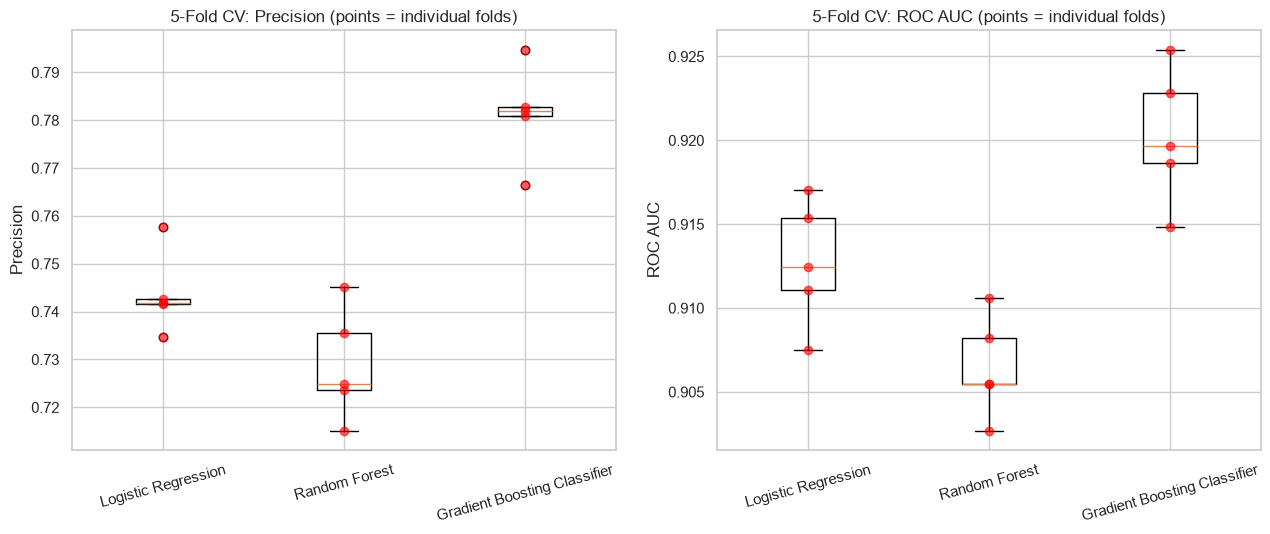

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
model_names = list(candidate_models.keys())

# Precision scatter points
for i, name in enumerate(model_names):
    y_precision = cv_results[name]["test_precision"]
    axes[0].scatter(
        [i + 1] * len(y_precision),
        y_precision,
        color="red",
        alpha=0.6,
        zorder=3,
    )

# ROC AUC scatter points
for i, name in enumerate(model_names):
    y_auc = cv_results[name]["test_roc_auc"]
    axes[1].scatter(
        [i + 1] * len(y_auc),
        y_auc,
        color="red",
        alpha=0.6,
        zorder=3,
    )

# Precision boxplot
axes[0].boxplot([cv_results[name]["test_precision"] for name in model_names])
axes[0].set_xticks(range(1, len(model_names) + 1))
axes[0].set_xticklabels(model_names, rotation=15)
axes[0].set_ylabel("Precision")
axes[0].set_title("5-Fold CV: Precision (points = individual folds)")

# ROC AUC boxplot
axes[1].boxplot([cv_results[name]["test_roc_auc"] for name in model_names])
axes[1].set_xticks(range(1, len(model_names) + 1))
axes[1].set_xticklabels(model_names, rotation=15)
axes[1].set_ylabel("ROC AUC")
axes[1].set_title("5-Fold CV: ROC AUC (points = individual folds)")

plt.tight_layout()
plt.savefig("charts/boxplot.png", dpi=200, bbox_inches="tight")
plt.show()

In [93]:
from scipy import stats

precision_scores_by_model = {
    name: cv_results[name]["test_precision"]
    for name in candidate_models
}

mean_precision = {
    name: scores.mean()
    for name, scores in precision_scores_by_model.items()
}

ranked_models = sorted(
    mean_precision,
    key=mean_precision.get,
    reverse=True,
)

top1, top2 = ranked_models[0], ranked_models[1]

print(f"Top model by mean Precision: {top1} ({mean_precision[top1]:.4f})")
print(f"Runner-up by mean Precision: {top2} ({mean_precision[top2]:.4f})")
print(f"Raw mean difference:         {mean_precision[top1] - mean_precision[top2]:.4f}")

t_stat, p_value_t = stats.ttest_rel(
    precision_scores_by_model[top1],
    precision_scores_by_model[top2],
)

w_stat, p_value_w = stats.wilcoxon(
    precision_scores_by_model[top1],
    precision_scores_by_model[top2],
)

print(f"\nPaired t-test: t = {t_stat:.3f}, p = {p_value_t:.4f}")
print(f"Wilcoxon test: W = {w_stat:.3f}, p = {p_value_w:.4f}")

Top model by mean Precision: Gradient Boosting Classifier (0.7813)
Runner-up by mean Precision: Logistic Regression (0.7436)
Raw mean difference:         0.0377

Paired t-test: t = 10.527, p = 0.0005
Wilcoxon test: W = 0.000, p = 0.0625


In [94]:
# Fit each full pipeline once on all feature
fitted_pipelines = {}
for name, clf in candidate_models.items():
    pipe = Pipeline([
        ("feature_engineering", feature_engineer),
        ("preprocessing", preprocessor_fe),
        ("clf", clf),
    ])
    pipe.fit(X_train_fe_input, y_train)
    fitted_pipelines[name] = pipe

feature_names_fe = fitted_pipelines["Logistic Regression"].named_steps["preprocessing"].get_feature_names_out()

# Logistic Regression coefficients
logreg_coefs = fitted_pipelines["Logistic Regression"].named_steps["clf"].coef_[0]
logreg_coef_df = pd.DataFrame({"feature": feature_names_fe, "coefficient": logreg_coefs})

engineered_feature_prefixes = ("num__log_capital_gain", "num__edu_hours_interaction", "num__net_capital",
                                "bin__has_capital_gain", "bin__has_capital_loss", "bin__higher_education",
                                "cat__age_bucket", "cat__hours_bucket")
engineered_mask = logreg_coef_df["feature"].str.startswith(engineered_feature_prefixes)
print("Logistic Regression coefficients for engineered features only:")
display(logreg_coef_df[engineered_mask].sort_values("coefficient", ascending=False))

# Random Forest 
for tree_model_name in ["Random Forest"]:
    importances = fitted_pipelines[tree_model_name].named_steps["clf"].feature_importances_
    imp_df = pd.DataFrame({"feature": feature_names_fe, "importance": importances})
    imp_mask = imp_df["feature"].str.startswith(engineered_feature_prefixes)
    print(f"\n{tree_model_name} feature importances for engineered features only:")
    display(imp_df[imp_mask].sort_values("importance", ascending=False))

Logistic Regression coefficients for engineered features only:


,feature,coefficient
8,num__net_capital,1.900654
96,cat__age_bucket_36-45,0.427566
97,cat__age_bucket_46-55,0.424839
102,cat__hours_bucket_over_41_50,0.390840
101,cat__hours_bucket_heavy_50plus,0.286462
6,num__log_capital_gain,0.262992
11,bin__higher_education,0.116314
95,cat__age_bucket_26-35,0.040649
98,cat__age_bucket_56-65,-0.010978
105,cat__hours_bucket_standard_36_40,-0.021807



Random Forest feature importances for engineered features only:


,feature,importance
7,num__edu_hours_interaction,0.080822
8,num__net_capital,0.051672
6,num__log_capital_gain,0.037640
11,bin__higher_education,0.027013
9,bin__has_capital_gain,0.010896
100,cat__age_bucket_<=25,0.010087
97,cat__age_bucket_46-55,0.008496
96,cat__age_bucket_36-45,0.008082
102,cat__hours_bucket_over_41_50,0.006593
95,cat__age_bucket_26-35,0.006537


In [95]:
best_model_name = ranked_models[0]
best_clf = candidate_models[best_model_name]

k_value = 65

pipe_full = Pipeline([
    ("feature_engineering", feature_engineer),
    ("preprocessing", preprocessor_fe),
    ("clf", best_clf),
])

pipe_selected = Pipeline([
    ("feature_engineering", feature_engineer),
    ("preprocessing", preprocessor_fe),
    ("select", SelectKBest(score_func=mutual_info_classif, k=k_value)),
    ("clf", best_clf),
])

results_compare = {}

for label, pipe in [
    ("Full feature set", pipe_full),
    (f"SelectKBest (k={k_value})", pipe_selected),
]:

    start = time.time()

    scores = cross_validate(
        pipe,
        X_train_fe_input,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
    )

    elapsed = time.time() - start

    results_compare[label] = {
        "precision_mean": scores["test_precision"].mean(),
        "precision_std": scores["test_precision"].std(),
        "recall_mean": scores["test_recall"].mean(),
        "recall_std": scores["test_recall"].std(),
        "f1_mean": scores["test_f1"].mean(),
        "f1_std": scores["test_f1"].std(),
        "roc_auc_mean": scores["test_roc_auc"].mean(),
        "total_fit_time_sec": elapsed,
    }

    print(
        f"{label:24s} "
        f"Precision = {scores['test_precision'].mean():.4f} +/- {scores['test_precision'].std():.4f} | "
        f"Recall = {scores['test_recall'].mean():.4f} +/- {scores['test_recall'].std():.4f} | "
        f"F1 = {scores['test_f1'].mean():.4f} +/- {scores['test_f1'].std():.4f} | "
        f"ROC AUC = {scores['test_roc_auc'].mean():.4f} | "
        f"Time = {elapsed:.1f}s"
    )

pd.DataFrame(results_compare).round(4)

Full feature set         Precision = 0.7813 +/- 0.0090 | Recall = 0.6009 +/- 0.0090 | F1 = 0.6793 +/- 0.0073 | ROC AUC = 0.9203 | Time = 44.4s
SelectKBest (k=65)       Precision = 0.7789 +/- 0.0112 | Recall = 0.5989 +/- 0.0035 | F1 = 0.6771 +/- 0.0041 | ROC AUC = 0.9192 | Time = 43.6s


,Full feature set,SelectKBest (k=65)
precision_mean,0.7813,0.7789
precision_std,0.0090,0.0112
recall_mean,0.6009,0.5989
recall_std,0.0090,0.0035
f1_mean,0.6793,0.6771
f1_std,0.0073,0.0041
roc_auc_mean,0.9203,0.9192
total_fit_time_sec,44.4191,43.6389


In [96]:
final_features_kept = {
    "raw_numeric": numeric_cols,
    "raw_categorical": categorical_cols,
    "engineered": ["age_bucket", "hours_bucket", "has_capital_gain", "has_capital_loss",
                   "higher_education", "log_capital_gain", "edu_hours_interaction", "net_capital"],
}

for group, feats in final_features_kept.items():
    print(f"{group} ({len(feats)}):")
    for f in feats:
        print(f"  - {f}")
    print()

total = sum(len(v) for v in final_features_kept.values())
print(f"Total features kept: {total}")

raw_numeric (6):
  - age
  - fnlwgt
  - education-num
  - capital-gain
  - capital-loss
  - hours-per-week

raw_categorical (7):
  - workclass
  - marital-status
  - occupation
  - relationship
  - race
  - sex
  - native-country

engineered (8):
  - age_bucket
  - hours_bucket
  - has_capital_gain
  - has_capital_loss
  - higher_education
  - log_capital_gain
  - edu_hours_interaction
  - net_capital

Total features kept: 21
